# ETF Crypto Relative Value Research Notebook

Author: Keane Gan

This notebook tests whether crypto ETFs exhibit a tradable relative-value relationship versus their underlying cryptocurrencies after unusually large ETF-versus-underlying residual moves.

A profitable signal could come from several mechanisms, including mean-reversion, ETF trading-hour limitations, stale ETF pricing, overnight crypto price discovery, or ETF catch-up behavior after the underlying cryptocurrency moves while the ETF market is closed.

**Universe note:** I use crypto ETFs that are intended to give relatively pure exposure to one underlying cryptocurrency. I exclude ETFs with mixed-asset baskets, covered-call income overlays, boosted-income mandates, futures-based mandates, staking mandates, or other unique strategies that could make the ETF return reflect something other than the underlying crypto exposure. The extended ETF list comes from the attached spreadsheet, but the code below keeps an explicit `Include` flag so the universe can be audited and adjusted.

The strategy uses **CVXPY** to choose daily portfolio weights instead of directly scaling each pair trade. The optimizer maximizes a signal-based expected return while penalizing risk and turnover. The main portfolio constraint is:

$$
\sum_i |w_{i,t}| \leq 1.00
$$

That means the strategy can be long and short, but total gross exposure cannot exceed 100% of capital.

The main validation workflow to test against our out of sample region:

1. Split the available model dates into a training sample and an out-of-sample period.
2. Run the parameter sweep only on the training sample.
3. Select one parameter set using the training-sample Sharpe ratio.
4. Freeze that parameter set before the OOS period.
5. Run exactly one final OOS backtest.
6. Treat that frozen-parameter OOS result as the main validation result.

## 1. Install and import packages

Run the install cell only if your environment does not already have the packages.

In [ ]:
# Uncomment if needed
# !pip install yfinance pandas numpy matplotlib statsmodels scipy cvxpy --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import cvxpy as cp
from IPython.display import display


pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

print("cvxpy version:", cp.__version__)


cvxpy version: 1.6.7


## 2. Define ETF-to-crypto mapping

The extended ETF universe below is based on the attached spreadsheet. I keep only single-underlying crypto exposure candidates for the main research universe and exclude products with income overlays, boosted exposure, mixed baskets, or futures/staking mandates that may have strategy-specific return drivers.

The ticker `BTC` below refers to the Grayscale Bitcoin Mini Trust ETF ticker on Yahoo Finance. The underlying crypto ticker is `BTC-USD`.


In [ ]:
# Include=True means the ETF is treated as a single-underlying, relatively pure exposure candidate.
# Include=False means the ETF is excluded from the main test because its mandate may include
# futures, staking, income overlays, boosted exposure, covered calls, or a mixed basket.

etf_universe = pd.DataFrame([
    # Bitcoin spot / trust style exposure
    {"ETF": "IBIT", "Name": "iShares Bitcoin Trust ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "FBTC", "Name": "Fidelity Wise Origin Bitcoin Fund", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "GBTC", "Name": "Grayscale Bitcoin Trust ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "BTC", "Name": "Grayscale Bitcoin Mini Trust ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "BITB", "Name": "Bitwise Bitcoin ETF Trust", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "ARKB", "Name": "ARK 21Shares Bitcoin ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "HODL", "Name": "VanEck Bitcoin ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "BTCO", "Name": "Invesco Galaxy Bitcoin ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "BRRR", "Name": "CoinShares Bitcoin ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "EZBC", "Name": "Franklin Bitcoin ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},
    {"ETF": "DEFI", "Name": "Hashdex Bitcoin ETF", "Underlying": "BTC-USD", "Exposure_Type": "single-asset Bitcoin", "Include": True},

    # Ethereum spot / trust style exposure
    {"ETF": "ETHA", "Name": "iShares Ethereum Trust ETF", "Underlying": "ETH-USD", "Exposure_Type": "single-asset Ethereum", "Include": True},
    {"ETF": "FETH", "Name": "Fidelity Ethereum Fund ETF", "Underlying": "ETH-USD", "Exposure_Type": "single-asset Ethereum", "Include": True},
    {"ETF": "ETHW", "Name": "Bitwise Ethereum ETF", "Underlying": "ETH-USD", "Exposure_Type": "single-asset Ethereum", "Include": True},
    {"ETF": "ETHV", "Name": "VanEck Ethereum ETF", "Underlying": "ETH-USD", "Exposure_Type": "single-asset Ethereum", "Include": True},
    {"ETF": "QETH", "Name": "Invesco Galaxy Ethereum ETF", "Underlying": "ETH-USD", "Exposure_Type": "single-asset Ethereum", "Include": True},

    # These may have shorter histories or unavailable yfinance data, so the notebook skips them if prices are missing.
    {"ETF": "XRPI", "Name": "Volatility Shares Trust XRP ETF", "Underlying": "XRP-USD", "Exposure_Type": "single-asset XRP candidate", "Include": True},
    {"ETF": "SOLZ", "Name": "Solana ETF", "Underlying": "SOL-USD", "Exposure_Type": "single-asset Solana candidate", "Include": True},

    # Excluded products
    {"ETF": "BITO", "Name": "ProShares Bitcoin ETF", "Underlying": "BTC-USD", "Exposure_Type": "futures-based", "Include": False},
    {"ETF": "ETH", "Name": "Grayscale Ethereum Staking Mini ETF", "Underlying": "ETH-USD", "Exposure_Type": "staking mandate", "Include": False},
    {"ETF": "ETHE", "Name": "Grayscale Ethereum Staking ETF", "Underlying": "ETH-USD", "Exposure_Type": "staking mandate", "Include": False},
    {"ETF": "BTCI", "Name": "NEOS Bitcoin High Income ETF", "Underlying": "BTC-USD", "Exposure_Type": "income overlay", "Include": False},
    {"ETF": "XBCI", "Name": "NEOS Boosted Bitcoin High Income ETF", "Underlying": "BTC-USD", "Exposure_Type": "boosted income overlay", "Include": False},
    {"ETF": "NEHI", "Name": "NEOS Ethereum High Income ETF", "Underlying": "ETH-USD", "Exposure_Type": "income overlay", "Include": False},
    {"ETF": "EETH", "Name": "ProShares Ether ETF", "Underlying": "ETH-USD", "Exposure_Type": "futures-based", "Include": False},
    {"ETF": "BAGY", "Name": "Amplify Bitcoin Max Income Covered Call ETF", "Underlying": "BTC-USD", "Exposure_Type": "covered-call income", "Include": False},
    {"ETF": "XRPM", "Name": "Amplify XRP 3% Monthly Premium Income ETF", "Underlying": "XRP-USD", "Exposure_Type": "option income", "Include": False},
    {"ETF": "EHY", "Name": "Amplify Ethereum Max Income Covered Call ETF", "Underlying": "ETH-USD", "Exposure_Type": "covered-call income", "Include": False},
    {"ETF": "ETTY", "Name": "Amplify Ethereum 3% Monthly Option Income ETF", "Underlying": "ETH-USD", "Exposure_Type": "option income", "Include": False},
    {"ETF": "SOLM", "Name": "Amplify Solana 3% Monthly Option Income ETF", "Underlying": "SOL-USD", "Exposure_Type": "option income", "Include": False},
    {"ETF": "DIME", "Name": "CoinShares Altcoins ETF", "Underlying": "MIXED", "Exposure_Type": "mixed basket", "Include": False},
])

etf_info = etf_universe.loc[etf_universe["Include"], ["ETF", "Name", "Underlying", "Exposure_Type"]].copy()
excluded_etfs = etf_universe.loc[~etf_universe["Include"], ["ETF", "Name", "Exposure_Type"]].copy()

print(f"Included ETFs: {len(etf_info)}")
print(f"Excluded ETFs: {len(excluded_etfs)}")

display(etf_info)
display(excluded_etfs)


Included ETFs: 18
Excluded ETFs: 13


,ETF,Name,Underlying,Exposure_Type
0,IBIT,iShares Bitcoin Trust ETF,BTC-USD,single-asset Bitcoin
1,FBTC,Fidelity Wise Origin Bitcoin Fund,BTC-USD,single-asset Bitcoin
2,GBTC,Grayscale Bitcoin Trust ETF,BTC-USD,single-asset Bitcoin
3,BTC,Grayscale Bitcoin Mini Trust ETF,BTC-USD,single-asset Bitcoin
4,BITB,Bitwise Bitcoin ETF Trust,BTC-USD,single-asset Bitcoin
5,ARKB,ARK 21Shares Bitcoin ETF,BTC-USD,single-asset Bitcoin
6,HODL,VanEck Bitcoin ETF,BTC-USD,single-asset Bitcoin
7,BTCO,Invesco Galaxy Bitcoin ETF,BTC-USD,single-asset Bitcoin
8,BRRR,CoinShares Bitcoin ETF,BTC-USD,single-asset Bitcoin
9,EZBC,Franklin Bitcoin ETF,BTC-USD,single-asset Bitcoin


,ETF,Name,Exposure_Type
18,BITO,ProShares Bitcoin ETF,futures-based
19,ETH,Grayscale Ethereum Staking Mini ETF,staking mandate
20,ETHE,Grayscale Ethereum Staking ETF,staking mandate
21,BTCI,NEOS Bitcoin High Income ETF,income overlay
22,XBCI,NEOS Boosted Bitcoin High Income ETF,boosted income overlay
23,NEHI,NEOS Ethereum High Income ETF,income overlay
24,EETH,ProShares Ether ETF,futures-based
25,BAGY,Amplify Bitcoin Max Income Covered Call ETF,covered-call income
26,XRPM,Amplify XRP 3% Monthly Premium Income ETF,option income
27,EHY,Amplify Ethereum Max Income Covered Call ETF,covered-call income


## 3. Download daily prices from yfinance

The notebook uses adjusted close prices when available. ETF data starts when the ETFs began trading, so the shared sample will begin in 2024 for Bitcoin ETFs and later for ETHA.

In [ ]:
START_DATE = "2024-01-01"
END_DATE = None  # None means latest available from yfinance

tickers = sorted(set(etf_info["ETF"]).union(set(etf_info["Underlying"])).union({"SPY"}))
print(tickers)

raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True,
)

# yfinance sometimes returns a MultiIndex and sometimes a single-level frame.
if isinstance(raw.columns, pd.MultiIndex):
    close = raw["Close"].copy()
else:
    close = raw[["Close"]].copy()

close = close.dropna(how="all")
close.tail()

['ARKB', 'BITB', 'BRRR', 'BTC', 'BTC-USD', 'BTCO', 'DEFI', 'ETH-USD', 'ETHA', 'ETHV', 'ETHW', 'EZBC', 'FBTC', 'FETH', 'GBTC', 'HODL', 'IBIT', 'QETH', 'SOL-USD', 'SOLZ', 'SPY', 'XRP-USD', 'XRPI']


Ticker,ARKB,BITB,BRRR,BTC,BTC-USD,BTCO,DEFI,ETH-USD,ETHA,ETHV,ETHW,EZBC,FBTC,FETH,GBTC,HODL,IBIT,QETH,SOL-USD,SOLZ,SPY,XRP-USD,XRPI
Date,,,,,,,,,,,,,,,,,,,,,,,
2026-06-11,21.08,34.509998,17.930000,28.110001,63561.054688,63.25,72.083000,1672.280640,12.70,24.549999,12.03,36.740002,55.290001,16.75,49.320000,17.969999,36.049999,16.709999,66.822006,6.709,737.760010,1.141586,6.35
2026-06-12,21.08,34.520000,17.930000,28.129999,63543.199219,63.25,72.094002,1665.127808,12.57,24.340000,11.90,36.750000,55.349998,16.58,49.340000,17.969999,36.040001,16.559999,66.749275,6.695,741.750000,1.132059,6.28
2026-06-13,NaN,NaN,NaN,NaN,64421.324219,NaN,NaN,1680.214600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.872787,NaN,NaN,1.150045,NaN
2026-06-14,NaN,NaN,NaN,NaN,65710.398438,NaN,NaN,1724.613281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.166183,NaN,NaN,1.185829,NaN
2026-06-15,22.09,36.150002,18.780001,29.430000,66202.609375,66.25,75.320000,1789.199951,13.76,26.580000,13.04,38.490002,57.959999,18.15,51.650002,18.840000,37.740002,18.100000,73.839996,7.560,754.830017,1.237200,7.08


## 4. Clean prices and calculate returns

We keep only days with valid ETF and crypto data. Daily returns are close-to-close returns.

In [ ]:
available = [c for c in tickers if c in close.columns]
prices = close[available].copy().dropna(axis=1, how="all")

# Important:
# Crypto trades on weekends but ETFs do not. Forward filling ETF prices creates fake
# 0% ETF weekend returns against real crypto weekend returns, which can create a
# look-ahead/stale-price artifact.
rets = prices.pct_change(fill_method=None)

print("Available columns:", list(prices.columns))
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Rows:", len(prices))
print("Return calculation: pct_change(fill_method=None), no forward-filled ETF weekend returns")

rets.tail()


Available columns: ['ARKB', 'BITB', 'BRRR', 'BTC', 'BTC-USD', 'BTCO', 'DEFI', 'ETH-USD', 'ETHA', 'ETHV', 'ETHW', 'EZBC', 'FBTC', 'FETH', 'GBTC', 'HODL', 'IBIT', 'QETH', 'SOL-USD', 'SOLZ', 'SPY', 'XRP-USD', 'XRPI']
Date range: 2024-01-01 00:00:00 to 2026-06-15 00:00:00
Rows: 897
Return calculation: pct_change(fill_method=None), no forward-filled ETF weekend returns


Ticker,ARKB,BITB,BRRR,BTC,BTC-USD,BTCO,DEFI,ETH-USD,ETHA,ETHV,ETHW,EZBC,FBTC,FETH,GBTC,HODL,IBIT,QETH,SOL-USD,SOLZ,SPY,XRP-USD,XRPI
Date,,,,,,,,,,,,,,,,,,,,,,,
2026-06-11,0.02729,0.026778,0.027507,0.026662,0.034366,0.026786,0.026180,0.032184,0.034202,0.030646,0.031732,0.027118,0.026169,0.032039,0.027072,0.026857,0.027651,0.030845,0.057964,0.052392,0.016997,0.040419,0.042693
2026-06-12,0.00000,0.000290,0.000000,0.000711,-0.000281,0.000000,0.000153,-0.004277,-0.010236,-0.008554,-0.010806,0.000272,0.001085,-0.010149,0.000406,0.000000,-0.000277,-0.008977,-0.001088,-0.002087,0.005408,-0.008345,-0.011024
2026-06-13,NaN,NaN,NaN,NaN,0.013819,NaN,NaN,0.009060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031813,NaN,NaN,0.015888,NaN
2026-06-14,NaN,NaN,NaN,NaN,0.020010,NaN,NaN,0.026424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033299,NaN,NaN,0.031115,NaN
2026-06-15,NaN,NaN,NaN,NaN,0.007491,NaN,NaN,0.037450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.037571,NaN,NaN,0.043321,NaN


## 5. Build the ETF-crypto pair panel

For each ETF, we create ETF price, crypto price, ETF daily return, crypto daily return, rolling beta, and residual return after hedging crypto exposure.

In [ ]:
def rolling_beta(y: pd.Series, x: pd.Series, window: int = 30, min_periods: int = 20) -> pd.Series:
    # Rolling OLS beta of y on x using covariance / variance.
    cov = y.rolling(window, min_periods=min_periods).cov(x)
    var = x.rolling(window, min_periods=min_periods).var()
    beta = cov / var
    return beta.replace([np.inf, -np.inf], np.nan)

LOOKBACK_BETA = 30
LOOKBACK_Z = 20

pair_frames = []

for row in etf_info.itertuples(index=False):
    etf = row.ETF
    crypto = row.Underlying

    if etf not in prices.columns or crypto not in prices.columns:
        print(f"Skipping {etf}, missing {etf} or {crypto} in yfinance download")
        continue

    # Because this is a pair-specific trading calendar:
    # We keep only dates when both ETF and underlying crypto prices exist.
    # This makes Monday crypto return compare Friday-to-Monday crypto vs Friday-to-Monday ETF,
    # instead of accidentally comparing Sunday-to-Monday crypto vs Friday-to-Monday ETF.
    pair_px = prices[[etf, crypto]].dropna().copy()
    pair_ret = pair_px.pct_change(fill_method=None)

    df = pd.DataFrame(index=pair_px.index)
    df["ETF"] = etf
    df["Underlying"] = crypto
    df["etf_price"] = pair_px[etf]
    df["crypto_price"] = pair_px[crypto]
    df["etf_ret"] = pair_ret[etf]
    df["crypto_ret"] = pair_ret[crypto]

    df["beta"] = rolling_beta(df["etf_ret"], df["crypto_ret"], LOOKBACK_BETA)
    df["residual_ret"] = df["etf_ret"] - df["beta"] * df["crypto_ret"]
    df["resid_mean"] = df["residual_ret"].rolling(LOOKBACK_Z, min_periods=10).mean()
    df["resid_std"] = df["residual_ret"].rolling(LOOKBACK_Z, min_periods=10).std()
    df["z"] = (df["residual_ret"] - df["resid_mean"]) / df["resid_std"]

    pair_frames.append(df)

pairs = pd.concat(pair_frames).reset_index().rename(columns={"Date": "date", "index": "date"})
pairs = pairs.dropna(subset=["etf_ret", "crypto_ret", "beta", "z", "etf_price", "crypto_price"])

print("Pair dates are ETF-trading dates only. Weekend stale-price rows removed.")
pairs.head()


Pair dates are ETF-trading dates only. Weekend stale-price rows removed.


,date,ETF,Underlying,etf_price,crypto_price,etf_ret,crypto_ret,beta,residual_ret,resid_mean,resid_std,z
29,2024-02-23,IBIT,BTC-USD,29.160000,50731.949219,-0.018843,-0.011169,0.929330,-0.008463,0.001021,0.012606,-0.752328
30,2024-02-26,IBIT,BTC-USD,31.120001,54522.402344,0.067215,0.074715,0.922920,-0.001741,0.000770,0.011988,-0.209419
31,2024-02-27,IBIT,BTC-USD,32.590000,57085.371094,0.047236,0.047008,0.958516,0.002179,0.000887,0.011437,0.112955
32,2024-02-28,IBIT,BTC-USD,34.450001,62504.789062,0.057073,0.094935,0.858121,-0.024393,-0.001058,0.013003,-1.794703
33,2024-02-29,IBIT,BTC-USD,35.419998,61198.382812,0.028157,-0.020901,0.802163,0.044923,0.002227,0.017523,2.436493


## 6. Build ETF-versus-underlying relative-value alpha forecasts

Instead of directly scaling every pair trade from the z-score, the notebook converts pair-level signals into asset-level alpha forecasts and lets CVXPY decide final weights subject to a 100% gross-exposure cap.

The pair signal is the negative residual z-score passed through a bounded transformation:

$$
\text{signal}_{i,t} = -\tanh\left(\frac{z_{i,t}}{z_{\text{scale}}}\right)
$$

The intuition is that when the ETF outperforms its underlying cryptocurrency by an unusually large amount, the ETF leg receives a negative forecast and the underlying leg receives an offsetting positive forecast, adjusted by the estimated hedge ratio. When the ETF lags by an unusually large amount, the direction is reversed.

I describe this as a relative-value signal rather than claiming it is necessarily traditional mean reversion. The pattern may come from ETF/crypto timing effects, stale ETF marks, or ETFs catching up to crypto moves that happened outside ETF trading hours.

In [ ]:
ZSCALE = 1.5
ENTRY_Z = 0.75
ALPHA_MULTIPLIER = 1.0

pairs = pairs.copy()
pairs["raw_signal"] = -np.tanh(pairs["z"] / ZSCALE)
pairs["signal"] = np.where(pairs["z"].abs() >= ENTRY_Z, pairs["raw_signal"], 0.0) # if our raw signal is significant enough (>=0.75) we consider the trade

# Forecast the next-day residual return in daily return units.
# This is intentionally simple: stronger z-score dislocations get stronger forecasts,
# but tanh keeps extreme observations from dominating.
pairs["resid_vol"] = pairs["resid_std"].replace(0, np.nan)
pairs["pair_alpha"] = ALPHA_MULTIPLIER * pairs["signal"] * pairs["resid_vol"]

# signal > 0 means long ETF residual and short beta-adjusted crypto residual.
pairs["etf_alpha"] = pairs["pair_alpha"]
pairs["crypto_alpha"] = -pairs["beta"] * pairs["pair_alpha"] # we want to keep crypto market neutral exposure

pairs[["date", "ETF", "Underlying", "beta", "z", "signal", "pair_alpha", "etf_alpha", "crypto_alpha"]].tail(10)


,date,ETF,Underlying,beta,z,signal,pair_alpha,etf_alpha,crypto_alpha
9512,2026-06-02,SOLZ,SOL-USD,1.033216,1.120106,-0.633198,-0.008519,-0.008519,0.008802
9513,2026-06-03,SOLZ,SOL-USD,1.062070,-0.824914,0.500477,0.006822,0.006822,-0.007245
9514,2026-06-04,SOLZ,SOL-USD,1.042368,0.254962,0.000000,0.000000,0.000000,-0.000000
9515,2026-06-05,SOLZ,SOL-USD,1.053662,-0.289070,0.000000,0.000000,0.000000,-0.000000
9516,2026-06-08,SOLZ,SOL-USD,1.070315,0.825407,-0.500723,-0.006382,-0.006382,0.006831
9517,2026-06-09,SOLZ,SOL-USD,1.069093,0.019382,0.000000,0.000000,0.000000,-0.000000
9518,2026-06-10,SOLZ,SOL-USD,1.069195,0.153435,0.000000,0.000000,0.000000,-0.000000
9519,2026-06-11,SOLZ,SOL-USD,1.049566,-0.795936,0.485858,0.005013,0.005013,-0.005261
9520,2026-06-12,SOLZ,SOL-USD,1.047483,0.001276,0.000000,0.000000,0.000000,-0.000000
9521,2026-06-15,SOLZ,SOL-USD,1.086833,1.373605,-0.723874,-0.006956,-0.006956,0.007560


## 7. Optimize daily portfolio weights with CVXPY

For each trading date, the optimizer chooses portfolio weights by balancing expected return, risk, and trading costs:

$$
\max_w \quad \alpha_t^\top w
- \lambda w^\top \Sigma_t w
- \kappa \lVert w - w_{t-1} \rVert_1
$$

subject to the gross exposure constraint:

$$
\sum_i |w_i| \le 1.00
$$
The gross-exposure cap is the main change. It forces total absolute exposure to stay at or below 100%.

Other controls:

- `MAX_SINGLE_ASSET_WEIGHT` stops one ETF or crypto hedge from dominating.
- `RISK_AVERSION` penalizes volatile portfolios.
- `TURNOVER_PENALTY` discourages weights from jumping too much day to day.
- `MAX_NET_EXPOSURE` is optional. Set it to `None` if you only want the 100% gross cap.


In [ ]:
# Build asset-level alpha matrix from pair-level alpha forecasts
etf_alpha = pairs.pivot_table(index="date", columns="ETF", values="etf_alpha", aggfunc="sum").fillna(0.0)
crypto_alpha = pairs.pivot_table(index="date", columns="Underlying", values="crypto_alpha", aggfunc="sum").fillna(0.0)

alpha = pd.concat([etf_alpha, crypto_alpha], axis=1).groupby(level=0, axis=1).sum().sort_index()
alpha = alpha.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Optimization Constraints
MAX_ABS_EXPOSURE = 1.00 # sum(abs(weights)) <= 100%
MAX_SINGLE_ASSET_WEIGHT = 0.35 # max absolute weight in one asset
MAX_NET_EXPOSURE = None
COV_LOOKBACK = 30 # making my covariance matrix have a 30 day lookback
RISK_AVERSION = 5.0
TURNOVER_PENALTY = 0.0005
RIDGE = 1e-6 # prevents covariance matrix from being badly behaved if nearly singular

def make_psd(mat: np.ndarray, ridge: float = 1e-6) -> np.ndarray:
    """Force a covariance matrix to be symmetric positive semidefinite."""
    mat = np.asarray(mat, dtype=float)
    mat = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)
    mat = 0.5 * (mat + mat.T)

    if mat.size == 0:
        return mat

    vals, vecs = np.linalg.eigh(mat)
    vals = np.clip(vals, ridge, None) # we put a floor to the values of ridge as we do not want negative variance
    psd = (vecs * vals) @ vecs.T
    return 0.5 * (psd + psd.T)

def valid_weight_solution(vals, max_abs_exposure, max_single_asset_weight, max_net_exposure=None, tol=1e-5):
    vals = np.asarray(vals, dtype=float)
    if vals.ndim != 1 or not np.all(np.isfinite(vals)):
        return False
    if np.sum(np.abs(vals)) > max_abs_exposure + tol:
        return False
    if np.max(np.abs(vals)) > max_single_asset_weight + tol:
        return False
    if max_net_exposure is not None and abs(np.sum(vals)) > max_net_exposure + tol:
        return False
    return True

def solve_cvxpy_weights(
    alpha_vec: pd.Series,
    cov_mat: pd.DataFrame,
    prev_w: pd.Series | None = None,
    max_abs_exposure: float = 1.0,
    max_single_asset_weight: float = 0.35,
    max_net_exposure: float | None = None,
    risk_aversion: float = 5.0,
    turnover_penalty: float = 0.0005,
) -> pd.Series:
    assets = list(alpha_vec.index)
    n = len(assets)
    if n == 0:
        return pd.Series(dtype=float)

    a = alpha_vec.reindex(assets).replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(float)
    Sigma_raw = cov_mat.reindex(index=assets, columns=assets).fillna(0.0).values.astype(float)
    Sigma = make_psd(Sigma_raw, ridge=RIDGE)

    if prev_w is None:
        w_prev = np.zeros(n)
    else:
        w_prev = prev_w.reindex(assets).replace([np.inf, -np.inf], np.nan).fillna(0.0).values.astype(float)

    w = cp.Variable(n)

    expected_alpha = a @ w
    risk_penalty = risk_aversion * cp.quad_form(w, cp.psd_wrap(Sigma))
    trading_penalty = turnover_penalty * cp.norm1(w - w_prev)

    objective = cp.Maximize(expected_alpha - risk_penalty - trading_penalty) # Our target is to make optimal weights off our constraints
    constraints = [
        cp.norm1(w) <= max_abs_exposure,
        w <= max_single_asset_weight,
        w >= -max_single_asset_weight,
    ]

    if max_net_exposure is not None:
        constraints += [cp.sum(w) <= max_net_exposure, cp.sum(w) >= -max_net_exposure] # In the event we want to set a maximum net exposure

    problem = cp.Problem(objective, constraints) # create the full optimization problem

    installed = set(cp.installed_solvers())
    solver_order = [s for s in ["CLARABEL", "OSQP", "SCS"] if s in installed]

    for solver in solver_order:
        try:
            problem.solve(solver=solver, verbose=False)
            if w.value is None or problem.status not in {"optimal", "optimal_inaccurate"}:
                continue

            vals = np.asarray(w.value).ravel().astype(float)
            vals[np.abs(vals) < 1e-8] = 0.0

            # Fix tiny numerical cap violations, but reject genuinely bad solver output.
            gross = np.sum(np.abs(vals))
            if max_abs_exposure < gross <= max_abs_exposure + 1e-4:
                vals = vals * (max_abs_exposure / gross)

            if valid_weight_solution(vals, max_abs_exposure, max_single_asset_weight, max_net_exposure):
                return pd.Series(vals, index=assets)

        except Exception:
            pass

    # Fallback: no trade if the optimizer fails or returns an invalid solution.
    return pd.Series(0.0, index=assets)

# Solve one optimization per day.
asset_cols = list(alpha.columns)

# Use the alpha trading calendar to compute all returns.
# This avoids mixing crypto weekend returns with non-trading ETF rows.
asset_rets_for_cov = prices.reindex(alpha.index)[asset_cols].pct_change(fill_method=None).fillna(0.0)

target_weights_list = []
prev_target = pd.Series(0.0, index=asset_cols)

for date in alpha.index:
    hist = asset_rets_for_cov.loc[:date].tail(COV_LOOKBACK)
    if len(hist) < max(10, COV_LOOKBACK // 2):
        w_t = pd.Series(0.0, index=asset_cols)
    else:
        cov_t = hist.cov()
        w_t = solve_cvxpy_weights(
            alpha_vec=alpha.loc[date],
            cov_mat=cov_t,
            prev_w=prev_target,
            max_abs_exposure=MAX_ABS_EXPOSURE,
            max_single_asset_weight=MAX_SINGLE_ASSET_WEIGHT,
            max_net_exposure=MAX_NET_EXPOSURE,
            risk_aversion=RISK_AVERSION,
            turnover_penalty=TURNOVER_PENALTY,
        )
    target_weights_list.append(w_t.rename(date))
    prev_target = w_t.reindex(asset_cols).fillna(0.0)

target_weights = pd.DataFrame(target_weights_list).fillna(0.0)
target_weights.index.name = "date"

# Shift by one day so today's close-based signal is traded over tomorrow's close-to-close return.
trade_weights = target_weights.shift(1).fillna(0.0)

gross_exposure = trade_weights.abs().sum(axis=1)
net_exposure = trade_weights.sum(axis=1)

print("Average gross exposure:", gross_exposure.mean())
print("Max gross exposure:", gross_exposure.max())
print("Average net exposure:", net_exposure.mean())
print("Max absolute net exposure:", net_exposure.abs().max())

assert gross_exposure.max() <= MAX_ABS_EXPOSURE + 1e-5, "Gross exposure cap was violated."

trade_weights.tail()


Average gross exposure: 0.9009155390318897
Max gross exposure: 1.0000000000000002
Average net exposure: -0.004146338740155839
Max absolute net exposure: 0.4980071709602628


,ARKB,BITB,BRRR,BTC,BTC-USD,BTCO,DEFI,ETH-USD,ETHA,ETHV,ETHW,EZBC,FBTC,FETH,GBTC,HODL,IBIT,QETH,SOL-USD,SOLZ,XRP-USD,XRPI
date,,,,,,,,,,,,,,,,,,,,,,
2026-06-09,-4.731751e-08,0.000000e+00,-3.499997e-01,-6.669604e-08,3.500000e-01,-1.081245e-07,-2.624975e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.834882e-07,-1.931207e-01,0.000000e+00,-3.342010e-08,-5.421756e-08,-4.560314e-08,0.000000e+00,1.068788e-01,-2.140684e-08,0.000000e+00,0.000000e+00
2026-06-10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.500000e-01,-3.114633e-08,-6.906781e-08,-7.934000e-08,0.000000e+00,0.000000e+00,-2.999999e-01,0.000000e+00,0.000000e+00,0.000000e+00,-3.499999e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2026-06-11,2.946138e-08,2.907120e-08,2.998434e-08,2.926200e-08,2.771471e-08,2.954901e-08,3.422609e-08,3.499999e-01,8.699422e-07,9.093845e-06,1.361048e-01,2.986296e-08,2.851010e-08,-2.999964e-01,2.941084e-08,3.013092e-08,3.063547e-08,-2.082654e-01,1.700766e-08,7.026970e-08,0.000000e+00,4.166613e-08
2026-06-12,0.000000e+00,2.521099e-08,0.000000e+00,0.000000e+00,-3.500000e-01,2.836259e-08,2.000662e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.595929e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.991697e-01,2.507640e-01,0.000000e+00,0.000000e+00
2026-06-15,2.005177e-08,4.372772e-08,1.961313e-08,1.979892e-08,-3.499965e-01,4.619036e-08,2.000662e-01,2.675843e-08,1.534232e-08,1.425524e-08,1.439397e-08,1.962039e-08,5.294972e-08,1.505820e-08,2.040425e-08,1.993684e-08,2.058962e-08,1.421252e-08,-1.991697e-01,2.507640e-01,1.949873e-08,1.350829e-08


### Interpretation

The optimizer keeps average gross exposure around 90.09% and the maximum gross exposure at 100.00%, so the portfolio is staying within the intended gross exposure cap. Average net exposure is close to zero at about -0.41%, which suggests the strategy is mostly taking relative-value positions rather than a large directional long or short crypto bet. The maximum absolute net exposure is still meaningful at 49.80%, so some dates are not perfectly market neutral.


## 8. Backtest optimized weights with transaction costs

This backtest uses close-to-close returns and assumes the signal is known only after the close. Therefore, target weights from date `t` are shifted forward and applied to the next close-to-close return.

Transaction cost is modeled as a cost per dollar of turnover. I use **20 bps** as the main crypto project assumption and show 5, 10, and 20 bps sensitivity in the next section.

Because the optimizer caps gross exposure, the backtest should report max gross exposure at or below 100%.


In [ ]:
TCOST_BPS = 20
TCOST = TCOST_BPS / 10000

# Use the same alpha/trading calendar returns created above.
asset_rets = asset_rets_for_cov.reindex(target_weights.index)[target_weights.columns].fillna(0.0)

# Important return-alignment fix:
# target_weights are created from close-based residual/z-score information on date t.
# Those weights cannot earn date t close-to-close returns. They are executable from the next period.
executed_weights = target_weights.shift(1).fillna(0.0)
trade_weights = executed_weights.copy()

port_ret_gross = (executed_weights * asset_rets).sum(axis=1)
turnover = executed_weights.diff().abs().sum(axis=1).fillna(0.0)
port_ret_net = port_ret_gross - TCOST * turnover

bt = pd.DataFrame({
    "strategy_gross": port_ret_gross,
    "strategy_net": port_ret_net,
    "turnover": turnover,
    "gross_exposure": executed_weights.abs().sum(axis=1),
    "net_exposure": executed_weights.sum(axis=1),
})

bench_cols = {}

# Benchmarks must be measured on the same trading calendar as the strategy.
for col in ["BTC-USD", "ETH-USD", "SOL-USD", "XRP-USD", "SPY"]:
    if col in prices.columns:
        bench_cols[col] = prices[col].reindex(bt.index).pct_change(fill_method=None)

etf_cols = [t for t in etf_info["ETF"] if t in prices.columns]
if etf_cols:
    bench_cols["ETF_equal_weight"] = prices[etf_cols].reindex(bt.index).pct_change(fill_method=None).mean(axis=1)

bench = pd.DataFrame(bench_cols).fillna(0.0)
bt = bt.join(bench)

print(f"Main transaction cost assumption: {TCOST_BPS} bps per dollar of turnover")
print("Return alignment: target_weights.shift(1) is used for strategy returns")
bt.tail()


Main transaction cost assumption: 20 bps per dollar of turnover
Return alignment: target_weights.shift(1) is used for strategy returns


,strategy_gross,strategy_net,turnover,gross_exposure,net_exposure,BTC-USD,ETH-USD,SOL-USD,XRP-USD,SPY,ETF_equal_weight
date,,,,,,,,,,,
2026-06-09,0.000540,-0.003460,2.000000,1.000000,-0.086242,-0.022932,-0.031028,-0.027441,-0.026486,-0.002936,-0.021193
2026-06-10,0.007306,0.003306,2.000000,1.000000,-0.300000,-0.003155,-0.010728,-0.027725,-0.035186,-0.015766,-0.009579
2026-06-11,-0.000452,-0.001008,0.277854,0.994377,-0.022147,0.034366,0.032184,0.057964,0.040419,0.016997,0.030590
2026-06-12,-0.000178,-0.004166,1.994377,1.000000,-0.098339,-0.000281,-0.004277,-0.001088,-0.008345,0.005408,-0.003289
2026-06-15,0.005546,0.005546,0.000004,0.999997,-0.098336,0.041852,0.074512,0.106229,0.092876,0.017634,0.069145


### Interpretation

The main backtest applies the previous day's target weights to the next day's asset returns. Under the 20 bps transaction cost assumption, the sample output shows that transaction costs materially reduce daily returns because turnover is high. This makes net performance the more important result to evaluate than gross performance.


## 9. Exploratory full-sample performance and alpha/beta diagnostics

The first table reports annualized return, annualized volatility, Sharpe ratio, max drawdown, hit rate, and average daily turnover for an exploratory full-sample run.

This section is useful for diagnostics, but it is not the final validation result. The final validation result comes later, after parameters are selected only on the training sample and evaluated once on the frozen OOS sample.

The second table regresses the strategy's net returns against every downloaded benchmark that is relevant to the active universe. This includes BTC, ETH, and any additional underlying cryptos from the expanded ETF list, such as SOL or XRP when those ETFs are included and prices are available. It also includes SPY and the ETF equal-weight benchmark. The table reports annualized alpha, alpha t-stat, beta, correlation, volatility, max drawdown, turnover, and total net return after costs.

In [ ]:
def max_drawdown(ret: pd.Series) -> float:
    wealth = (1 + ret.fillna(0)).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    return dd.min()

def perf_stats(ret: pd.Series, turnover: pd.Series | None = None, periods: int = 252) -> pd.Series:
    ret = ret.dropna()
    ann_ret = (1 + ret).prod() ** (periods / max(len(ret), 1)) - 1
    ann_vol = ret.std() * np.sqrt(periods)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    out = pd.Series({
        "total_return": (1 + ret).prod() - 1,
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown(ret),
        "hit_rate": (ret > 0).mean(),
        "days": len(ret),
    })
    if turnover is not None:
        out["avg_daily_turnover"] = turnover.reindex(ret.index).mean()
    return out

def alpha_beta_stats(strategy_ret: pd.Series, benchmark_ret: pd.Series, turnover: pd.Series | None = None, periods: int = 252) -> pd.Series:
    reg = pd.concat([
        strategy_ret.rename("strategy"),
        benchmark_ret.rename("benchmark"),
    ], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    if len(reg) < 30 or reg["benchmark"].std() == 0:
        return pd.Series(dtype=float)

    X = sm.add_constant(reg["benchmark"])
    model = sm.OLS(reg["strategy"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    out = pd.Series({
        "total_net_return_after_costs": (1 + reg["strategy"]).prod() - 1,
        "alpha_ann": model.params.get("const", np.nan) * periods,
        "alpha_tstat": model.tvalues.get("const", np.nan),
        "beta": model.params.get("benchmark", np.nan),
        "correlation": reg["strategy"].corr(reg["benchmark"]),
        "ann_vol": reg["strategy"].std() * np.sqrt(periods),
        "max_drawdown": max_drawdown(reg["strategy"]),
        "days": len(reg),
    })

    if turnover is not None:
        out["avg_daily_turnover"] = turnover.reindex(reg.index).mean()

    return out

# Build benchmark set dynamically from the active ETF universe.
underlying_benchmarks = sorted(set(etf_info["Underlying"]))
market_benchmarks = ["SPY"]
extra_benchmarks = ["ETF_equal_weight"]
benchmark_return_cols = [c for c in underlying_benchmarks + market_benchmarks + extra_benchmarks if c in bt.columns]

print("Underlying crypto benchmarks included:", [c for c in underlying_benchmarks if c in bt.columns])
print("Other benchmarks included:", [c for c in market_benchmarks + extra_benchmarks if c in bt.columns])

# Only actual return series belong in the performance table.
return_cols = ["strategy_gross", "strategy_net"] + benchmark_return_cols

summary = pd.DataFrame({
    col: perf_stats(bt[col], bt["turnover"] if col.startswith("strategy") else None)
    for col in return_cols
}).T

exposure_summary = pd.Series({
    "avg_gross_exposure": bt["gross_exposure"].mean(),
    "max_gross_exposure": bt["gross_exposure"].max(),
    "avg_abs_net_exposure": bt["net_exposure"].abs().mean(),
    "max_abs_net_exposure": bt["net_exposure"].abs().max(),
    "avg_daily_turnover": bt["turnover"].mean(),
    "max_daily_turnover": bt["turnover"].max(),
}, name="value").to_frame()

benchmark_regressions = {}
for bench_col in benchmark_return_cols:
    benchmark_regressions[f"strategy_net_vs_{bench_col}"] = alpha_beta_stats(
        bt["strategy_net"],
        bt[bench_col],
        bt["turnover"]
    )

alpha_beta_table = pd.DataFrame(benchmark_regressions).T

display(summary.style.format({
    "total_return": "{:.2%}",
    "ann_return": "{:.2%}",
    "ann_vol": "{:.2%}",
    "sharpe": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "hit_rate": "{:.2%}",
    "avg_daily_turnover": "{:.2%}",
    "days": "{:.0f}",
}))

display(exposure_summary.style.format({"value": "{:.2%}"}))

if not alpha_beta_table.empty:
    display(alpha_beta_table.style.format({
        "total_net_return_after_costs": "{:.2%}",
        "alpha_ann": "{:.2%}",
        "alpha_tstat": "{:.2f}",
        "beta": "{:.2f}",
        "correlation": "{:.2f}",
        "ann_vol": "{:.2%}",
        "max_drawdown": "{:.2%}",
        "avg_daily_turnover": "{:.2%}",
        "days": "{:.0f}",
    }))
else:
    print("No benchmark alpha/beta table available. Check benchmark price downloads.")


Underlying crypto benchmarks included: ['BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD']
Other benchmarks included: ['SPY', 'ETF_equal_weight']


,ann_return,ann_vol,avg_daily_turnover,days,hit_rate,max_drawdown,sharpe,total_return
strategy_gross,150.02%,15.54%,107.71%,586,64.33%,-4.69%,9.65,742.28%
strategy_net,45.54%,15.27%,107.71%,586,54.10%,-7.35%,2.98,139.33%
BTC-USD,13.08%,49.00%,nan%,586,49.32%,-51.17%,0.27,33.09%
ETH-USD,-15.43%,69.79%,nan%,586,48.81%,-67.28%,-0.22,-32.28%
SOL-USD,-16.59%,77.53%,nan%,586,47.44%,-75.45%,-0.21,-34.41%
XRP-USD,44.59%,84.29%,nan%,586,46.25%,-69.16%,0.53,135.73%
SPY,21.40%,16.15%,nan%,586,57.51%,-18.76%,1.33,56.98%
ETF_equal_weight,3.61%,55.07%,nan%,586,47.95%,-58.49%,0.07,8.59%


,value
avg_gross_exposure,90.09%
max_gross_exposure,100.00%
avg_abs_net_exposure,17.76%
max_abs_net_exposure,49.80%
avg_daily_turnover,107.71%
max_daily_turnover,200.00%


,total_net_return_after_costs,alpha_ann,alpha_tstat,beta,correlation,ann_vol,max_drawdown,days,avg_daily_turnover
strategy_net_vs_BTC-USD,139.33%,39.79%,3.93,-0.04,-0.14,15.27%,-7.35%,586,107.71%
strategy_net_vs_ETH-USD,139.33%,38.86%,3.85,-0.02,-0.09,15.27%,-7.35%,586,107.71%
strategy_net_vs_SOL-USD,139.33%,38.91%,3.85,-0.02,-0.09,15.27%,-7.35%,586,107.71%
strategy_net_vs_XRP-USD,139.33%,40.12%,3.90,-0.02,-0.11,15.27%,-7.35%,586,107.71%
strategy_net_vs_SPY,139.33%,39.89%,3.83,-0.06,-0.06,15.27%,-7.35%,586,107.71%
strategy_net_vs_ETF_equal_weight,139.33%,39.42%,3.91,-0.04,-0.14,15.27%,-7.35%,586,107.71%


### Interpretation

These full-sample diagnostics are helpful, but they should be treated as exploratory rather than as final model validation. They help check whether the strategy is simply a disguised long-crypto trade and whether transaction costs overwhelm the signal.

The alpha/beta diagnostics are useful because they compare the strategy against BTC, ETH, SOL, XRP, SPY, and an ETF equal-weight benchmark when those series are available. Low benchmark beta and low correlation would support the interpretation that the strategy is mainly expressing ETF-versus-underlying relative-value views rather than simple directional crypto exposure.

The cleaner evidence comes later: parameters are selected only on the training sample and then evaluated once in the frozen-parameter OOS test.

## 10. Transaction cost sensitivity

The base notebook uses 20 bps. The table below reruns the already-shifted return stream at 5, 10, and 20 bps per dollar of turnover so we can see how much of the result depends on light transaction cost assumptions.


In [ ]:
cost_sensitivity = []

for bps in [5, 10, 20]:
    net_ret_bps = port_ret_gross - (bps / 10000) * turnover
    stats = perf_stats(net_ret_bps, turnover)
    stats["tcost_bps"] = bps
    cost_sensitivity.append(stats)

cost_sensitivity = pd.DataFrame(cost_sensitivity).set_index("tcost_bps")

display(cost_sensitivity.style.format({
    "total_return": "{:.2%}",
    "ann_return": "{:.2%}",
    "ann_vol": "{:.2%}",
    "sharpe": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "hit_rate": "{:.2%}",
    "avg_daily_turnover": "{:.2%}",
    "days": "{:.0f}",
}))


,total_return,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,days,avg_daily_turnover
tcost_bps,,,,,,,,
5.000000,515.20%,118.43%,15.43%,7.67,-4.87%,61.43%,586,107.71%
10.000000,349.23%,90.80%,15.35%,5.92,-5.31%,58.53%,586,107.71%
20.000000,139.33%,45.54%,15.27%,2.98,-7.35%,54.10%,586,107.71%


### Interpretation

The transaction cost sensitivity shows that performance depends heavily on trading costs. At 5 bps, the strategy has a 7.67 Sharpe and 515.20% total return. At 10 bps, Sharpe falls to 5.92 and total return falls to 346.23%. At 20 bps, Sharpe falls further to 2.98 and total return falls to 139.33%. The strategy still works at 20 bps in this sample, but the large performance drop confirms that implementation costs are one of the biggest practical risks.


## 11. Plot cumulative returns

The cumulative return plot includes the strategy, all active underlying crypto benchmarks from the ETF universe, SPY, and the ETF equal-weight benchmark when available. This means newer included underlyings such as Solana and XRP appear as `SOL-USD` and `XRP-USD` benchmark curves when downloaded successfully.


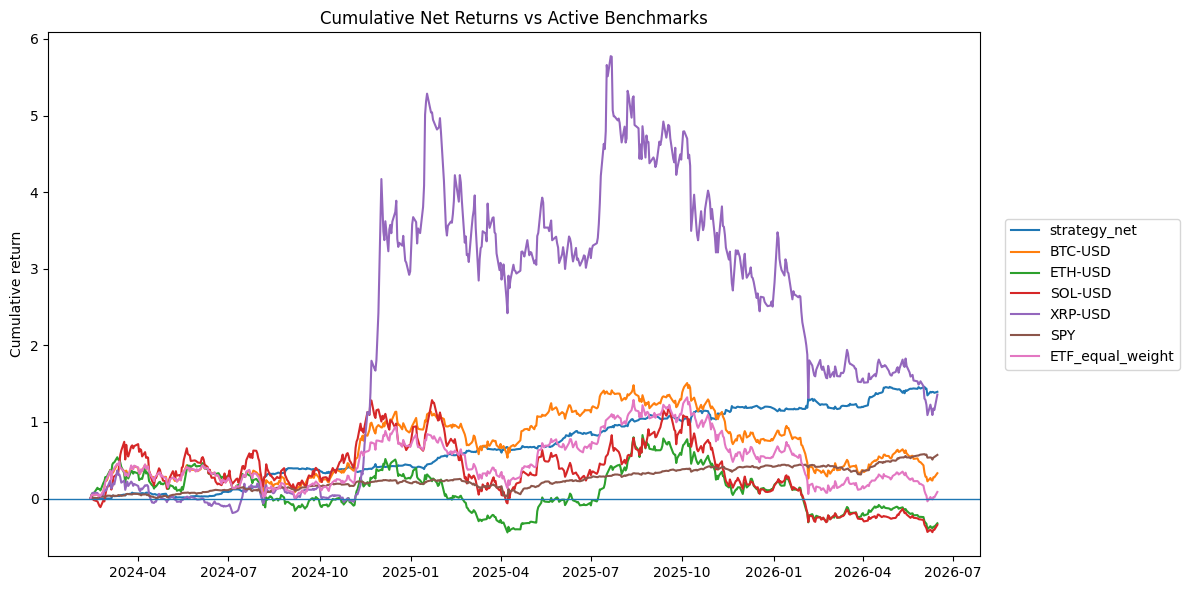

In [ ]:
plot_cols = ["strategy_net"] + benchmark_return_cols
plot_cols = [c for c in plot_cols if c in bt.columns]

cum = (1 + bt[plot_cols].fillna(0)).cumprod() - 1

plt.figure(figsize=(12, 6))
for col in cum.columns:
    plt.plot(cum.index, cum[col], label=col)
plt.axhline(0, linewidth=1)
plt.title("Cumulative Net Returns vs Active Benchmarks")
plt.ylabel("Cumulative return")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


### Interpretation

The cumulative return plot helps show whether the strategy's return path is distinct from the underlying crypto benchmarks. The key thing to look for is whether the strategy compounds more smoothly than BTC, ETH, SOL, XRP, SPY, and the ETF equal-weight benchmark. Based on the summary table, the strategy appears to deliver returns with much lower drawdown than the crypto benchmarks, which is consistent with a relative-value signal rather than a pure directional crypto trade.


## 12. Inspect optimizer behavior


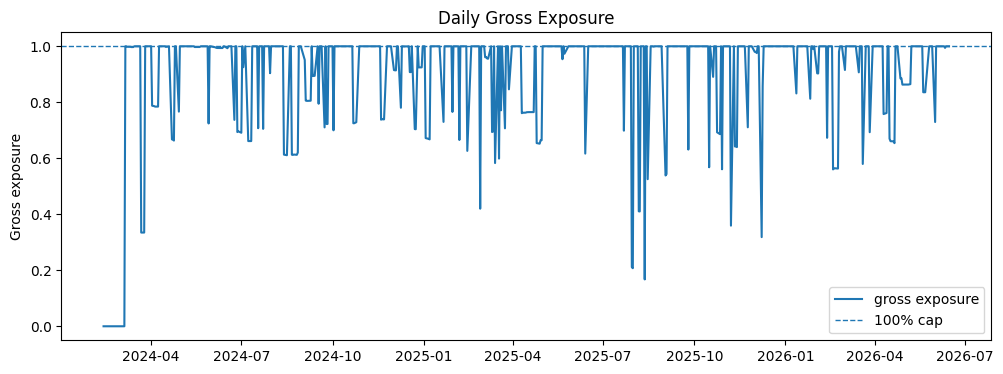

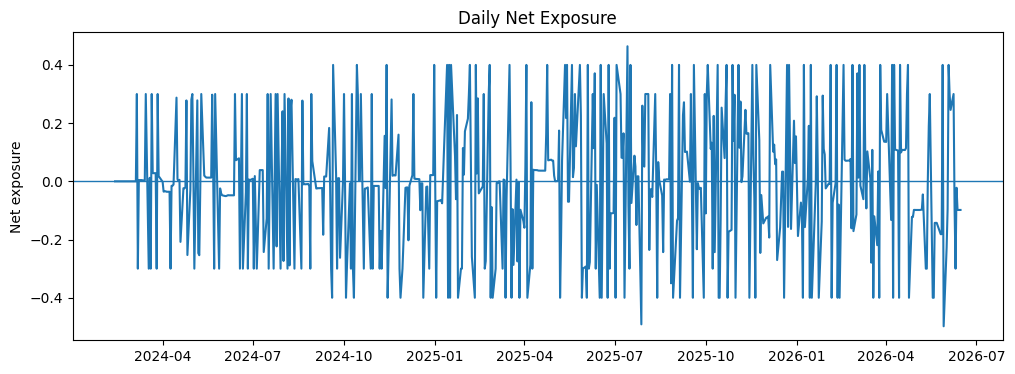

Max gross exposure: 1.0000000000000002
Gross cap respected: True


z                                  signal                               pair_alpha                      \
          mean       std       min       max      mean       std       min       max       mean       std       min   
ETF                                                                                                                   
ARKB -0.002817  0.966085 -3.443599  3.405787 -0.000716  0.437563 -0.978901  0.979928  -0.000034  0.005762 -0.018840   
BITB -0.002821  0.965512 -3.431093  3.384680  0.001163  0.437056 -0.978305  0.979593  -0.000021  0.005725 -0.018872   
BRRR -0.002498  0.967078 -3.449635  3.463513  0.000554  0.437390 -0.980448  0.980087  -0.000010  0.005701 -0.018572   
BTC   0.005145  0.962535 -3.436808  3.328958 -0.004138  0.432647 -0.976651  0.979747  -0.000075  0.005080 -0.016801   
BTCO -0.002884  0.966107 -3.438926  3.429495 -0.005107  0.437276 -0.979550  0.979803  -0.000074  0.005701 -0.018706   
DEFI -0.004401  0.968916 -3.457325  3.277415 -0.001288  0.444488 -0.975011  0.980288  -0.000069  0.006044 -0.018787   
ETHA  0.002946  0.959904 -3.522001  2.927552 -0.010346  0.430822 -0.960451  0.981902  -0.000184  0.008060 -0.028444   
ETHV  0.002505  0.959455 -3.532704  2.915244 -0.008148  0.427492 -0.959810  0.982156  -0.000167  0.007984 -0.028714   
ETHW  0.001890  0.961953 -3.518306  2.975177 -0.006113  0.429842 -0.962840  0.981813  -0.000103  0.007969 -0.028612   
EZBC -0.003136  0.966263 -3.428411  3.392127 -0.000292  0.438191 -0.978517  0.979521  -0.000024  0.005742 -0.018701   
FBTC -0.002526  0.965494 -3.457335  3.360176 -0.003815  0.438354 -0.977592  0.980288  -0.000062  0.005786 -0.018826   
FETH  0.002536  0.960646 -3.530886  2.884801 -0.006906  0.427484 -0.958180  0.982113  -0.000146  0.007980 -0.028553   
GBTC -0.002834  0.973551 -3.441104  3.402185  0.002811  0.440636 -0.978800  0.979861  -0.000002  0.005753 -0.018342   
HODL -0.002891  0.966096 -3.434531  3.340988 -0.001272  0.437509 -0.977018  0.979686  -0.000046  0.005708 -0.018856   
IBIT -0.002688  0.965229 -3.425381  3.403285  0.000658  0.436936 -0.978831  0.979439  -0.000023  0.005784 -0.019272   
QETH  0.002463  0.961950 -3.520652  2.882321 -0.008106  0.429239 -0.958045  0.981870  -0.000174  0.007945 -0.028866   
SOLZ  0.012928  0.953760 -3.023219  2.743490  0.001618  0.439118 -0.949728  0.965105   0.000021  0.009266 -0.029950   
XRPI  0.009196  0.927917 -3.268091  3.099727 -0.011213  0.417847 -0.968436  0.974702  -0.000226  0.008822 -0.034284   

               etf_alpha                               crypto_alpha                                
           max      mean       std       min       max         mean       std       min       max  
ETF                                                                                                
ARKB  0.021844 -0.000034  0.005762 -0.018840  0.021844     0.000053  0.005236 -0.019222  0.016438  
BITB  0.021879 -0.000021  0.005725 -0.018872  0.021879     0.000039  0.005208 -0.018990  0.016258  
BRRR  0.021794 -0.000010  0.005701 -0.018572  0.021794     0.000036  0.005183 -0.018863  0.016481  
BTC   0.020378 -0.000075  0.005080 -0.016801  0.020378     0.000094  0.004632 -0.018168  0.015775  
BTCO  0.021662 -0.000074  0.005701 -0.018706  0.021662     0.000089  0.005167 -0.018911  0.016345  
DEFI  0.021455 -0.000069  0.006044 -0.018787  0.021455     0.000071  0.005457 -0.018549  0.016725  
ETHA  0.024210 -0.000184  0.008060 -0.028444  0.024210     0.000160  0.007323 -0.024884  0.024655  
ETHV  0.024200 -0.000167  0.007984 -0.028714  0.024200     0.000137  0.007254 -0.024702  0.024589  
ETHW  0.024849 -0.000103  0.007969 -0.028612  0.024849     0.000090  0.007201 -0.024173  0.024245  
EZBC  0.022008 -0.000024  0.005742 -0.018701  0.022008     0.000046  0.005245 -0.018973  0.016462  
FBTC  0.022177 -0.000062  0.005786 -0.018826  0.022177     0.000081  0.005273 -0.019130  0.016548  
FETH  0.024181 -0.000146  0.007980 -0.028553  0.024181     0.000122  0.007236 -0.024823  0.024676  
GBTC  0.02183

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(bt.index, bt["gross_exposure"], label="gross exposure")
plt.axhline(MAX_ABS_EXPOSURE, linewidth=1, linestyle="--", label="100% cap")
plt.title("Daily Gross Exposure")
plt.ylabel("Gross exposure")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(bt.index, bt["net_exposure"])
plt.axhline(0, linewidth=1)
plt.title("Daily Net Exposure")
plt.ylabel("Net exposure")
plt.show()

print("Max gross exposure:", bt["gross_exposure"].max())
print("Gross cap respected:", bool(bt["gross_exposure"].max() <= MAX_ABS_EXPOSURE + 1e-5))

signal_stats = pairs.groupby("ETF")[["z", "signal", "pair_alpha", "etf_alpha", "crypto_alpha"]].agg(["mean", "std", "min", "max"])
signal_stats


### Interpretation

The exposure plots show how aggressively the optimizer uses the portfolio budget over time. The gross exposure is often close to the 100% cap, which means the optimizer frequently finds enough signal to use most of the allowed capital. The net exposure plot is centered closer to zero, which supports the idea that the strategy is generally expressing ETF-versus-crypto relative-value views instead of simply timing crypto market direction.


## 13. ETF-by-ETF residual predictability test

Here we test whether today's ETF-versus-underlying residual z-score predicts the **next tradable residual return**.

A negative coefficient means high residual z-scores tend to be followed by lower next tradable residual returns, and low residual z-scores tend to be followed by higher next tradable residual returns:

$$
\epsilon_{i,t+1} = a + b z_{i,t} + u_{i,t+1}
$$

Interpretation of results:

**Z coefficient:** a negative coefficient is consistent with residual reversal or ETF/underlying catch-up behavior.

**t-stat:** describes how statistically strong the coefficient is. A t-stat below about -2 suggests stronger evidence that the z-score contains predictive information.

**P-value:** p-values below 0.05 are usually treated as statistically meaningful.

**$R^2$:** measures how much of the next tradable residual-return variation is explained by today's z-score.

This diagnostic should not be described as proof of classic mean reversion. Strong results could also reflect ETF close timing, crypto trading hours, stale marks, or other ETF-versus-underlying timing effects.

In [ ]:
reg_table = (
    pd.DataFrame(reg_results)
    .sort_values("coef_z", ascending=True)   # most negative z coefficient first
    .reset_index(drop=True)
)

note = (
    "Note: Pairs are ranked by coef_z, with the most negative z coefficients at the top. "
    "More negative coef_z values indicate stronger mean reversion because a higher z-score "
    "predicts a lower next tradable residual return."
)

print(note)

display(
    reg_table.style
    .hide(axis="index")
    .format({
        "coef_z": "{:.3e}",
        "t_z": "{:.3e}",
        "p_z": "{:.3e}",
        "r2": "{:.3e}",
    })
)

Note: Pairs are ranked by coef_z, with the most negative z coefficients at the top. More negative coef_z values indicate stronger mean reversion because a higher z-score predicts a lower next tradable residual return.


ETF,nobs,coef_z,t_z,p_z,r2,first_signal_date,last_signal_date
SOLZ,281,-1.138e-02,-1.102e+01,2.913e-28,2.725e-01,2025-05-01 00:00:00,2026-06-12 00:00:00
XRPI,237,-1.065e-02,-6.879e+00,6.027e-12,2.290e-01,2025-07-07 00:00:00,2026-06-12 00:00:00
ETHA,446,-9.951e-03,-1.356e+01,6.850e-42,2.648e-01,2024-09-03 00:00:00,2026-06-12 00:00:00
ETHV,446,-9.931e-03,-1.348e+01,2.005e-41,2.659e-01,2024-09-03 00:00:00,2026-06-12 00:00:00
FETH,446,-9.908e-03,-1.337e+01,8.918e-41,2.656e-01,2024-09-03 00:00:00,2026-06-12 00:00:00
ETHW,446,-9.833e-03,-1.300e+01,1.278e-38,2.617e-01,2024-09-03 00:00:00,2026-06-12 00:00:00
QETH,446,-9.832e-03,-1.328e+01,3.151e-40,2.641e-01,2024-09-03 00:00:00,2026-06-12 00:00:00
DEFI,585,-7.158e-03,-1.299e+01,1.488e-38,2.601e-01,2024-02-13 00:00:00,2026-06-12 00:00:00
IBIT,578,-7.009e-03,-1.296e+01,2.075e-38,2.604e-01,2024-02-23 00:00:00,2026-06-12 00:00:00
ARKB,578,-7.004e-03,-1.288e+01,5.946e-38,2.628e-01,2024-02-23 00:00:00,2026-06-12 00:00:00


### Interpretation

This regression checks whether the residual z-score has next-period predictive content at the individual ETF-pair level.

Negative coefficients are consistent with a reversal or catch-up pattern in the ETF-versus-underlying residual. That is supportive of the trading signal.

The regression is best viewed as supporting evidence for an ETF/underlying relative-value signal, not as definitive proof of traditional fair-value mean reversion.

## 14. Training-sample parameter selection

To avoid tuning leakage, the parameter sweep below is run only on the training sample.

The workflow is:

1. Build the available model-date index.
2. Use the first 70% of model dates as the training sample.
3. Reserve the last 30% as the OOS period.
4. Sweep parameter combinations only through the training end date.
5. Select one parameter set using the highest training-sample Sharpe ratio.
6. Freeze that selected parameter set before looking at the OOS period.

The OOS period is not used for model selection.

In [ ]:
def combine_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Combine duplicate asset columns created when multiple ETFs share the same underlying."""
    if df.empty:
        return df
    return df.T.groupby(level=0).sum().T


def build_alpha_from_pairs(
    lookback_beta=30,
    lookback_z=20,
    entry_z=0.75,
    zscale=1.5,
    alpha_multiplier=1.0,
):
    """Build asset-level alpha forecasts from ETF/underlying residual signals."""
    local_frames = []

    for row in etf_info.itertuples(index=False):
        etf = row.ETF
        crypto = row.Underlying

        if etf not in prices.columns or crypto not in prices.columns:
            continue

        pair_px = prices[[etf, crypto]].dropna().copy()
        pair_ret = pair_px.pct_change(fill_method=None)

        df = pd.DataFrame(index=pair_px.index)
        df["ETF"] = etf
        df["Underlying"] = crypto
        df["etf_ret"] = pair_ret[etf]
        df["crypto_ret"] = pair_ret[crypto]
        df["beta"] = rolling_beta(
            df["etf_ret"],
            df["crypto_ret"],
            lookback_beta,
            max(10, lookback_beta // 2),
        )
        df["residual_ret"] = df["etf_ret"] - df["beta"] * df["crypto_ret"]
        df["resid_mean"] = df["residual_ret"].rolling(
            lookback_z,
            min_periods=max(5, lookback_z // 2),
        ).mean()
        df["resid_std"] = df["residual_ret"].rolling(
            lookback_z,
            min_periods=max(5, lookback_z // 2),
        ).std()
        df["z"] = (df["residual_ret"] - df["resid_mean"]) / df["resid_std"]
        df = df.dropna(subset=["z", "beta", "resid_std", "etf_ret", "crypto_ret"])

        df["raw_signal"] = -np.tanh(df["z"] / zscale)
        df["signal"] = np.where(df["z"].abs() >= entry_z, df["raw_signal"], 0.0)
        df["pair_alpha"] = alpha_multiplier * df["signal"] * df["resid_std"]
        df["etf_alpha"] = df["pair_alpha"]
        df["crypto_alpha"] = -df["beta"] * df["pair_alpha"]

        local_frames.append(df.reset_index().rename(columns={"Date": "date", "index": "date"}))

    if not local_frames:
        return pd.DataFrame()

    p = pd.concat(local_frames, ignore_index=True)
    etf_alpha_local = p.pivot_table(index="date", columns="ETF", values="etf_alpha", aggfunc="sum").fillna(0.0)
    crypto_alpha_local = p.pivot_table(index="date", columns="Underlying", values="crypto_alpha", aggfunc="sum").fillna(0.0)

    alpha_local = combine_duplicate_columns(pd.concat([etf_alpha_local, crypto_alpha_local], axis=1)).sort_index()
    alpha_local = alpha_local.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return alpha_local


def run_cvxpy_backtest_returns(
    entry_z=0.75,
    risk_aversion=5.0,
    turnover_penalty=0.0020,
    lookback_beta=30,
    lookback_z=20,
    start_date=None,
    end_date=None,
    calculation_end_date=None,
):
    """
    Run the CVXPY strategy using specified parameters and return daily results.

    The optimizer is evaluated sequentially through time. For training-sample parameter
    selection, calculation_end_date is set to TRAIN_END so the training sweep does not
    even calculate OOS-period weights. For the final OOS test, weights are generated
    through the OOS period using only information available up to each date, and the
    returned performance is sliced to the OOS window.
    """
    local_alpha = build_alpha_from_pairs(
        lookback_beta=lookback_beta,
        lookback_z=lookback_z,
        entry_z=entry_z,
        zscale=ZSCALE,
        alpha_multiplier=ALPHA_MULTIPLIER,
    )
    if local_alpha.empty:
        return None

    if calculation_end_date is not None:
        local_alpha = local_alpha.loc[local_alpha.index <= pd.Timestamp(calculation_end_date)].copy()
        if local_alpha.empty:
            return None

    cols = list(local_alpha.columns)
    local_asset_rets = (
        prices
        .reindex(local_alpha.index)[cols]
        .pct_change(fill_method=None)
        .fillna(0.0)
    )

    prev = pd.Series(0.0, index=cols)
    weight_rows = []

    for date in local_alpha.index:
        hist = local_asset_rets.loc[:date].tail(COV_LOOKBACK)

        if len(hist) < max(10, COV_LOOKBACK // 2):
            w_t = pd.Series(0.0, index=cols)
        else:
            w_t = solve_cvxpy_weights(
                alpha_vec=local_alpha.loc[date],
                cov_mat=hist.cov(),
                prev_w=prev,
                max_abs_exposure=MAX_ABS_EXPOSURE,
                max_single_asset_weight=MAX_SINGLE_ASSET_WEIGHT,
                max_net_exposure=MAX_NET_EXPOSURE,
                risk_aversion=risk_aversion,
                turnover_penalty=turnover_penalty,
            )

        weight_rows.append(w_t.rename(date))
        prev = w_t.reindex(cols).fillna(0.0)

    # Shift weights by one day so today's close-based signal is not allowed to earn today's return.
    target_weight_df = pd.DataFrame(weight_rows).fillna(0.0)
    executed_weight_df = target_weight_df.shift(1).fillna(0.0)
    aligned_rets = local_asset_rets.reindex(executed_weight_df.index)[executed_weight_df.columns].fillna(0.0)

    gross_ret = (executed_weight_df * aligned_rets).sum(axis=1)
    turnover = executed_weight_df.diff().abs().sum(axis=1).fillna(0.0)
    net_ret = gross_ret - TCOST * turnover

    out = pd.DataFrame({
        "gross_ret": gross_ret,
        "net_ret": net_ret,
        "turnover": turnover,
        "gross_exposure": executed_weight_df.abs().sum(axis=1),
        "net_exposure": executed_weight_df.sum(axis=1),
    })

    if start_date is not None:
        out = out.loc[out.index >= pd.Timestamp(start_date)].copy()
    if end_date is not None:
        out = out.loc[out.index <= pd.Timestamp(end_date)].copy()

    if out.empty:
        return None

    # Rebase cumulative returns within the requested evaluation window.
    out["cum_net"] = (1 + out["net_ret"]).cumprod() - 1
    out["cum_gross"] = (1 + out["gross_ret"]).cumprod() - 1

    return out, executed_weight_df.reindex(out.index).fillna(0.0)


# Build the train/OOS split once and reuse it for selection and final validation.
SPLIT_FRACTION_TRAIN = 0.70
BASE_LOOKBACK_BETA = 30
BASE_LOOKBACK_Z = 20

base_alpha_for_split = build_alpha_from_pairs(
    lookback_beta=BASE_LOOKBACK_BETA,
    lookback_z=BASE_LOOKBACK_Z,
    entry_z=0.75,
    zscale=ZSCALE,
    alpha_multiplier=ALPHA_MULTIPLIER,
)

all_model_dates = base_alpha_for_split.index.sort_values()
if len(all_model_dates) < 50:
    raise ValueError("Not enough model dates to create a reliable train/OOS split.")

split_idx = int(len(all_model_dates) * SPLIT_FRACTION_TRAIN)
split_idx = min(max(split_idx, 1), len(all_model_dates) - 1)

TRAIN_START = all_model_dates[0]
TRAIN_END = all_model_dates[split_idx - 1]
OOS_START = all_model_dates[split_idx]
OOS_END = all_model_dates[-1]

assert TRAIN_END < OOS_START, "Train/OOS split is not strictly ordered."

print(f"Training sample: {TRAIN_START.date()} to {TRAIN_END.date()} ({split_idx} trading days)")
print(f"OOS sample:      {OOS_START.date()} to {OOS_END.date()} ({len(all_model_dates) - split_idx} trading days)")


# Training-only parameter sweep.
entry_z_values = [0.50, 0.75, 1.00, 1.25]
risk_aversion_values = [2.0, 5.0, 10.0]
turnover_penalty_values = [0.0020]

train_sweep = []

for ez in entry_z_values:
    for ra in risk_aversion_values:
        for tp in turnover_penalty_values:
            result = run_cvxpy_backtest_returns(
                entry_z=ez,
                risk_aversion=ra,
                turnover_penalty=tp,
                lookback_beta=BASE_LOOKBACK_BETA,
                lookback_z=BASE_LOOKBACK_Z,
                start_date=TRAIN_START,
                end_date=TRAIN_END,
                calculation_end_date=TRAIN_END,
            )
            if result is None:
                continue

            bt_train, w_train = result
            stats = perf_stats(bt_train["net_ret"], bt_train["turnover"])
            stats["entry_z"] = ez
            stats["risk_aversion"] = ra
            stats["turnover_penalty"] = tp
            stats["final_cum_return"] = bt_train["cum_net"].iloc[-1]
            stats["max_gross"] = bt_train["gross_exposure"].max()
            stats["train_start"] = TRAIN_START.date()
            stats["train_end"] = TRAIN_END.date()
            train_sweep.append(stats)

train_sweep_df = (
    pd.DataFrame(train_sweep)
    .sort_values(["sharpe", "ann_return"], ascending=[False, False])
    .reset_index(drop=True)
)

if train_sweep_df.empty:
    raise ValueError("Training sweep produced no valid parameter rows.")

# Selection rule: choose the single best training-sample Sharpe ratio.
# Annualized return is used only as a tie-breaker through the sort above.
selected_row = train_sweep_df.iloc[0]
SELECTED_ENTRY_Z = float(selected_row["entry_z"])
SELECTED_RISK_AVERSION = float(selected_row["risk_aversion"])
SELECTED_TURNOVER_PENALTY = float(selected_row["turnover_penalty"])

print("Selection rule: highest training-sample Sharpe ratio; annualized return tie-breaker.")
print(f"Frozen parameters: entry_z={SELECTED_ENTRY_Z:.2f}, risk_aversion={SELECTED_RISK_AVERSION:.2f}, turnover_penalty={SELECTED_TURNOVER_PENALTY:.5f}")

formatters = {
    "total_return": "{:.2%}",
    "ann_return": "{:.2%}",
    "ann_vol": "{:.2%}",
    "sharpe": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "hit_rate": "{:.2%}",
    "avg_daily_turnover": "{:.2%}",
    "final_cum_return": "{:.2%}",
    "max_gross": "{:.2%}",
    "entry_z": "{:.2f}",
    "risk_aversion": "{:.2f}",
    "turnover_penalty": "{:.5f}",
    "days": "{:.0f}",
}

train_display_cols = [
    "train_start",
    "train_end",
    "entry_z",
    "risk_aversion",
    "turnover_penalty",
    "total_return",
    "ann_return",
    "ann_vol",
    "sharpe",
    "max_drawdown",
    "hit_rate",
    "avg_daily_turnover",
    "final_cum_return",
    "max_gross",
    "days",
]

display(train_sweep_df[train_display_cols].style.format(formatters))

selected_params_df = pd.DataFrame([selected_row])[[
    "train_start",
    "train_end",
    "entry_z",
    "risk_aversion",
    "turnover_penalty",
    "ann_return",
    "ann_vol",
    "sharpe",
    "max_drawdown",
    "hit_rate",
    "avg_daily_turnover",
    "final_cum_return",
    "max_gross",
    "days",
]]

selected_params_df.index = ["Selected on training Sharpe"]
display(selected_params_df.style.format(formatters))

Training sample: 2024-02-06 to 2025-09-29 (413 trading days)
OOS sample:      2025-09-30 to 2026-06-15 (178 trading days)
Selection rule: highest training-sample Sharpe ratio; annualized return tie-breaker.
Frozen parameters: entry_z=1.00, risk_aversion=5.00, turnover_penalty=0.00200


,train_start,train_end,entry_z,risk_aversion,turnover_penalty,total_return,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,avg_daily_turnover,final_cum_return,max_gross,days
0,2024-02-06,2025-09-29,1.00,5.00,0.00200,162.79%,80.31%,14.42%,5.57,-5.34%,56.66%,74.83%,162.79%,100.00%,413
1,2024-02-06,2025-09-29,1.00,10.00,0.00200,124.97%,64.01%,12.88%,4.97,-5.80%,55.93%,74.02%,124.97%,100.00%,413
2,2024-02-06,2025-09-29,1.00,2.00,0.00200,173.33%,84.69%,18.03%,4.70,-9.18%,54.96%,74.59%,173.33%,100.00%,413
3,2024-02-06,2025-09-29,0.75,5.00,0.00200,130.58%,66.49%,15.46%,4.30,-4.86%,56.42%,96.11%,130.58%,100.00%,413
4,2024-02-06,2025-09-29,0.75,10.00,0.00200,109.87%,57.20%,13.65%,4.19,-4.84%,54.48%,94.35%,109.87%,100.00%,413
5,2024-02-06,2025-09-29,0.75,2.00,0.00200,151.30%,75.46%,18.52%,4.07,-5.88%,54.00%,96.59%,151.30%,100.00%,413
6,2024-02-06,2025-09-29,1.25,10.00,0.00200,93.58%,49.63%,12.44%,3.99,-6.25%,56.42%,53.63%,93.58%,100.00%,413
7,2024-02-06,2025-09-29,1.25,5.00,0.00200,103.31%,54.18%,14.21%,3.81,-6.23%,56.17%,53.93%,103.31%,100.00%,413
8,2024-02-06,2025-09-29,1.25,2.00,0.00200,90.72%,48.28%,18.57%,2.60,-12.52%,53.51%,53.48%,90.72%,100.00%,413
9,2024-02-06,2025-09-29,0.50,10.00,0.00200,59.03%,32.72%,15.71%,2.08,-13.64%,51.82%,120.43%,59.03%,100.00%,413


,train_start,train_end,entry_z,risk_aversion,turnover_penalty,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,avg_daily_turnover,final_cum_return,max_gross,days
Selected on training Sharpe,2024-02-06,2025-09-29,1.00,5.00,0.00200,80.31%,14.42%,5.57,-5.34%,56.66%,74.83%,162.79%,100.00%,413


### Training-only selection visualization

This section keeps the parameter-selection view before the final OOS test, but it only uses the training sample.

The goal is to make the selection process transparent without leaking OOS information into model choice. The selected parameter set is still the highest training-sample Sharpe ratio, with annualized return used only as a tie-breaker. The other rankings below are diagnostics for discussion, not additional OOS selection rules.


Note: Transaction costs are standardized to 20 bps, which is closer to realistic trading costs. All parameter selection diagnostics below use the training sample only. No OOS results are used for parameter selection.
Training-only grid sorted by selection rule: highest training Sharpe, then annualized return.


training_sharpe_rank,entry_z,risk_aversion,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,avg_daily_turnover,final_cum_return,days
1,1.00,5.00,80.31%,14.42%,5.57,-5.34%,56.66%,74.83%,162.79%,413
2,1.00,10.00,64.01%,12.88%,4.97,-5.80%,55.93%,74.02%,124.97%,413
3,1.00,2.00,84.69%,18.03%,4.70,-9.18%,54.96%,74.59%,173.33%,413
4,0.75,5.00,66.49%,15.46%,4.30,-4.86%,56.42%,96.11%,130.58%,413
5,0.75,10.00,57.20%,13.65%,4.19,-4.84%,54.48%,94.35%,109.87%,413
6,0.75,2.00,75.46%,18.52%,4.07,-5.88%,54.00%,96.59%,151.30%,413
7,1.25,10.00,49.63%,12.44%,3.99,-6.25%,56.42%,53.63%,93.58%,413
8,1.25,5.00,54.18%,14.21%,3.81,-6.23%,56.17%,53.93%,103.31%,413
9,1.25,2.00,48.28%,18.57%,2.60,-12.52%,53.51%,53.48%,90.72%,413
10,0.50,10.00,32.72%,15.71%,2.08,-13.64%,51.82%,120.43%,59.03%,413


Training-only diagnostic leaders. These are not OOS-selected results.


diagnostic_view,entry_z,risk_aversion,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,avg_daily_turnover,final_cum_return,days
Selected for OOS / Highest Sharpe,1.00,5.00,80.31%,14.42%,5.57,-5.34%,56.66%,74.83%,162.79%,413
Highest annualized return,1.00,2.00,84.69%,18.03%,4.70,-9.18%,54.96%,74.59%,173.33%,413
Highest hit rate,1.00,5.00,80.31%,14.42%,5.57,-5.34%,56.66%,74.83%,162.79%,413
Lowest drawdown,0.75,10.00,57.20%,13.65%,4.19,-4.84%,54.48%,94.35%,109.87%,413


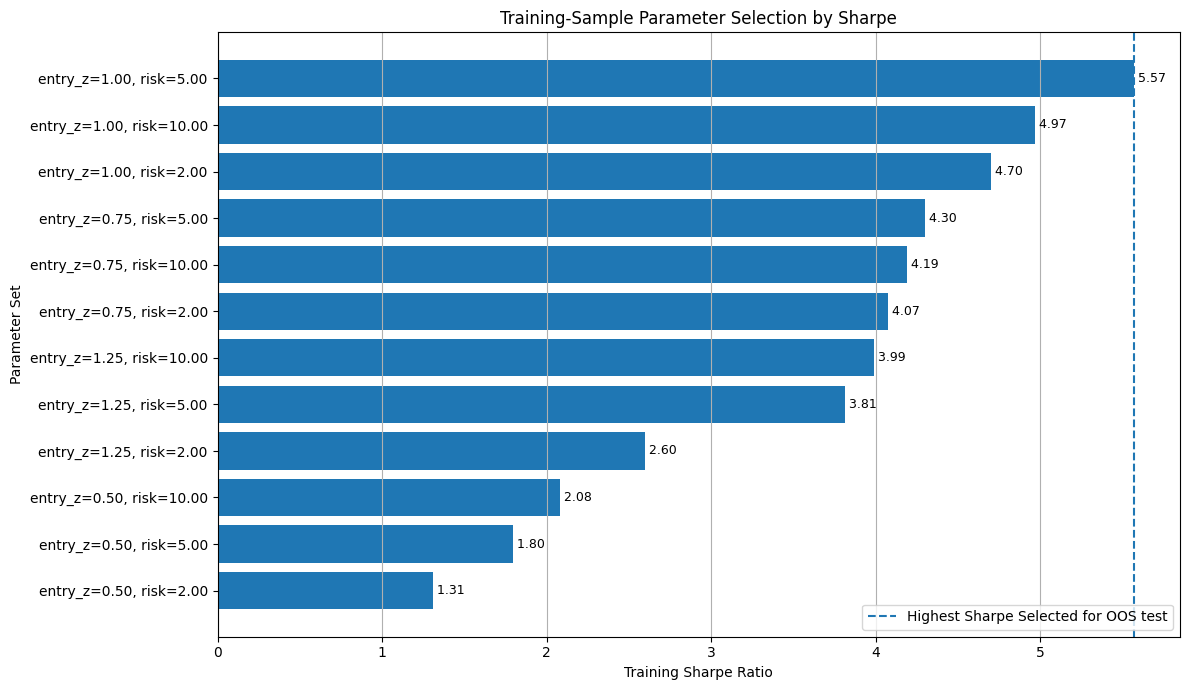

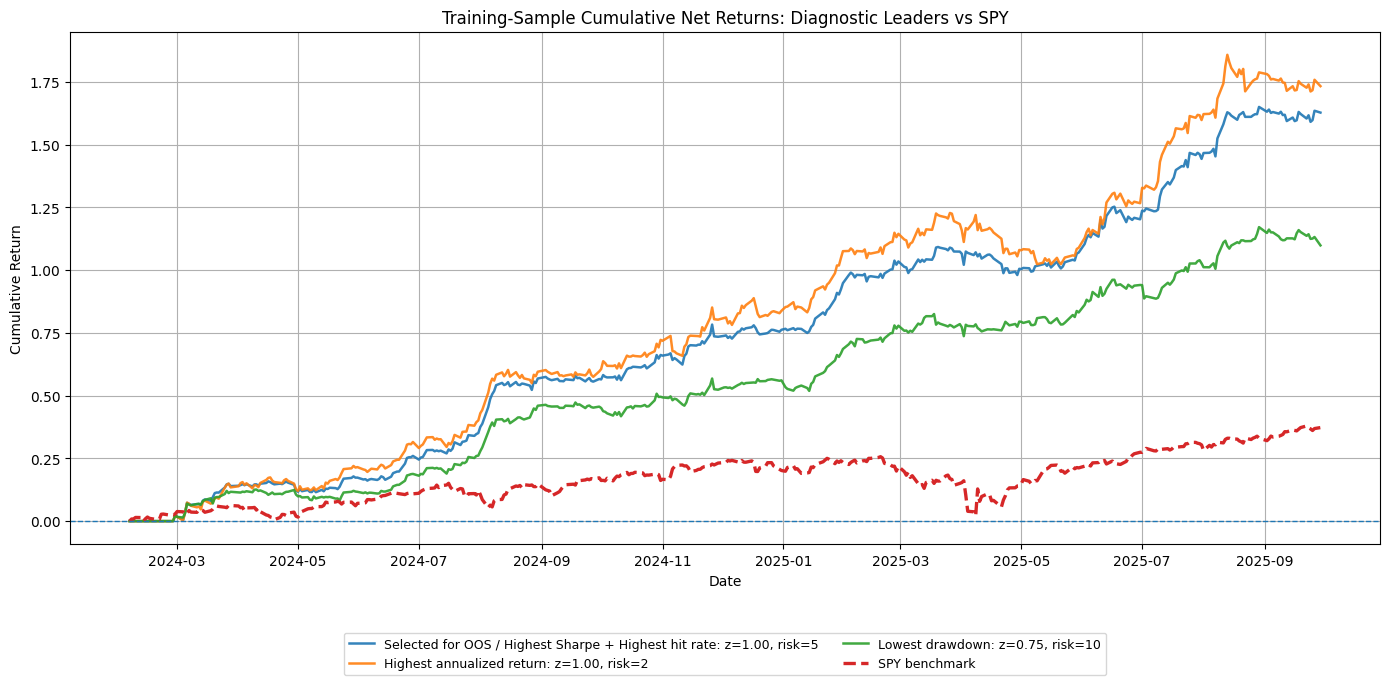

In [ ]:
# Training-only selection diagnostics and visualization.
# This intentionally uses train_sweep_df only. No OOS results are used here.
selection_visual_df = train_sweep_df.copy()

print(
    "Note: Transaction costs are standardized to 20 bps, which is closer to realistic trading costs. "
    "All parameter selection diagnostics below use the training sample only. "
    "No OOS results are used for parameter selection."
)

selection_visual_df["parameter_label"] = selection_visual_df.apply(
    lambda r: (
        f"entry_z={r['entry_z']:.2f}, "
        f"risk={r['risk_aversion']:.2f}"
    ),
    axis=1,
)

selection_visual_df["training_sharpe_rank"] = (
    selection_visual_df["sharpe"]
    .rank(method="min", ascending=False)
    .astype(int)
)

selection_display_cols = [
    "training_sharpe_rank",
    "entry_z",
    "risk_aversion",
    "ann_return",
    "ann_vol",
    "sharpe",
    "max_drawdown",
    "hit_rate",
    "avg_daily_turnover",
    "final_cum_return",
    "days",
]

# Identify diagnostic leaders using training-sample metrics only.
# max_drawdown is usually negative, so idxmax gives the least severe drawdown.
leader_specs = [
    ("Selected for OOS / Highest Sharpe", selection_visual_df["sharpe"].idxmax()),
    ("Highest annualized return", selection_visual_df["ann_return"].idxmax()),
    ("Highest hit rate", selection_visual_df["hit_rate"].idxmax()),
    ("Lowest drawdown", selection_visual_df["max_drawdown"].idxmax()),
]

leader_idx_by_metric = {
    "sharpe": selection_visual_df["sharpe"].idxmax(),
    "ann_return": selection_visual_df["ann_return"].idxmax(),
    "hit_rate": selection_visual_df["hit_rate"].idxmax(),
    "max_drawdown": selection_visual_df["max_drawdown"].idxmax(),
}

def highlight_training_leaders(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)

    highlight_style = "background-color: darkgreen; color: white; font-weight: bold;"

    if "sharpe" in data.columns:
        styles.loc[leader_idx_by_metric["sharpe"], "sharpe"] = highlight_style

    if "ann_return" in data.columns:
        styles.loc[leader_idx_by_metric["ann_return"], "ann_return"] = highlight_style

    if "hit_rate" in data.columns:
        styles.loc[leader_idx_by_metric["hit_rate"], "hit_rate"] = highlight_style

    if "max_drawdown" in data.columns:
        styles.loc[leader_idx_by_metric["max_drawdown"], "max_drawdown"] = highlight_style

    return styles

print("Training-only grid sorted by selection rule: highest training Sharpe, then annualized return.")

selection_table = (
    selection_visual_df[selection_display_cols]
    .sort_values(["sharpe", "ann_return"], ascending=[False, False])
)

display(
    selection_table
    .style
    .format(formatters)
    .apply(highlight_training_leaders, axis=None)
    .hide(axis="index")
)

# Show diagnostic leaders using training-sample metrics only.
leader_rows = []
for diagnostic, idx in leader_specs:
    row = selection_visual_df.loc[idx].copy()
    row["diagnostic_view"] = diagnostic
    leader_rows.append(row)

train_selection_leaders_df = pd.DataFrame(leader_rows)[[
    "diagnostic_view",
    "entry_z",
    "risk_aversion",
    "ann_return",
    "ann_vol",
    "sharpe",
    "max_drawdown",
    "hit_rate",
    "avg_daily_turnover",
    "final_cum_return",
    "days",
]]

print("Training-only diagnostic leaders. These are not OOS-selected results.")

display(
    train_selection_leaders_df
    .style
    .format(formatters)
    .hide(axis="index")
)

# Bar chart of the top training candidates by Sharpe.
top_n = min(12, len(selection_visual_df))
top_train_candidates = (
    selection_visual_df
    .sort_values(["sharpe", "ann_return"], ascending=[False, False])
    .head(top_n)
    .sort_values("sharpe", ascending=True)
)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_train_candidates["parameter_label"], top_train_candidates["sharpe"])

plt.axvline(
    float(selected_row["sharpe"]),
    linestyle="--",
    linewidth=1.5,
    label="Highest Sharpe Selected for OOS test"
)

for bar in bars:
    width = bar.get_width()
    y_position = bar.get_y() + bar.get_height() / 2
    plt.text(
        width,
        y_position,
        f" {width:.2f}",
        va="center",
        fontsize=9
    )

plt.title("Training-Sample Parameter Selection by Sharpe")
plt.xlabel("Training Sharpe Ratio")
plt.ylabel("Parameter Set")
plt.legend(loc="lower right")
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()

# Cumulative return view using training results only.
# This shows only the diagnostic leaders over time and compares them to SPY.
diagnostics_by_idx = {}

for diagnostic, idx in leader_specs:
    diagnostics_by_idx.setdefault(idx, []).append(diagnostic)

diagnostic_leader_curves = {}

for idx, diagnostics in diagnostics_by_idx.items():
    row = selection_visual_df.loc[idx]

    result = run_cvxpy_backtest_returns(
        entry_z=float(row["entry_z"]),
        risk_aversion=float(row["risk_aversion"]),
        turnover_penalty=float(row["turnover_penalty"]),
        lookback_beta=BASE_LOOKBACK_BETA,
        lookback_z=BASE_LOOKBACK_Z,
        start_date=TRAIN_START,
        end_date=TRAIN_END,
        calculation_end_date=TRAIN_END,
    )

    if result is None:
        continue

    bt_train_candidate, _ = result

    diagnostic_label = " + ".join(diagnostics)

    label = (
        f"{diagnostic_label}: "
        f"z={row['entry_z']:.2f}, "
        f"risk={row['risk_aversion']:.0f}"
    )

    diagnostic_leader_curves[label] = bt_train_candidate["cum_net"]

train_curves_df = pd.DataFrame(diagnostic_leader_curves).sort_index()

if "SPY" in prices.columns and not train_curves_df.empty:
    full_train_calendar = all_model_dates[all_model_dates <= train_curves_df.index.max()]

    spy_train_rets = (
        prices["SPY"]
        .reindex(full_train_calendar)
        .pct_change(fill_method=None)
        .reindex(train_curves_df.index)
        .fillna(0.0)
    )

    train_curves_df["SPY benchmark"] = (1 + spy_train_rets).cumprod() - 1

plt.figure(figsize=(14, 7))

for col in train_curves_df.columns:
    if col == "SPY benchmark":
        plt.plot(
            train_curves_df.index,
            train_curves_df[col],
            linestyle="--",
            linewidth=2.4,
            label=col
        )
    else:
        plt.plot(
            train_curves_df.index,
            train_curves_df[col],
            linewidth=1.8,
            alpha=0.9,
            label=col
        )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Training-Sample Cumulative Net Returns: Diagnostic Leaders vs SPY")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()

### Interpretation

This section is now the model-selection step rather than a full-sample robustness check.

The parameter grid is evaluated only on the training period. The selected model is the single parameter combination with the highest training-sample Sharpe ratio, with annualized return used only as a tie-breaker. Those parameters are stored as `SELECTED_ENTRY_Z` and `SELECTED_RISK_AVERSION`

The table and charts above are intentionally training-only. They let a reader see how the selected parameter set compared with alternatives before the OOS test, without using OOS performance to choose parameters.

No OOS performance is calculated or used in this section.


## 15. Final frozen-parameter out-of-sample backtest

This section runs exactly one OOS backtest.

The parameters come from the training-only selection step above and are frozen before the OOS period begins. The preceding selection tables and charts are allowed because they use only the training sample.

This means the OOS result is not chosen from an OOS grid and is not ranked against alternative OOS parameter settings.

This is the main validation result of the notebook.


,oos_start,oos_end,entry_z,risk_aversion,turnover_penalty,total_return,ann_return,ann_vol,sharpe,max_drawdown,hit_rate,avg_daily_turnover,final_cum_return,max_gross,days
Frozen-parameter OOS result,2025-09-30,2026-06-15,1.00,5.00,0.00200,24.43%,36.26%,15.32%,2.37,-6.70%,50.56%,92.13%,24.43%,100.00%,178


OOS benchmark columns included: ['BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD', 'SPY', 'ETF_equal_weight']


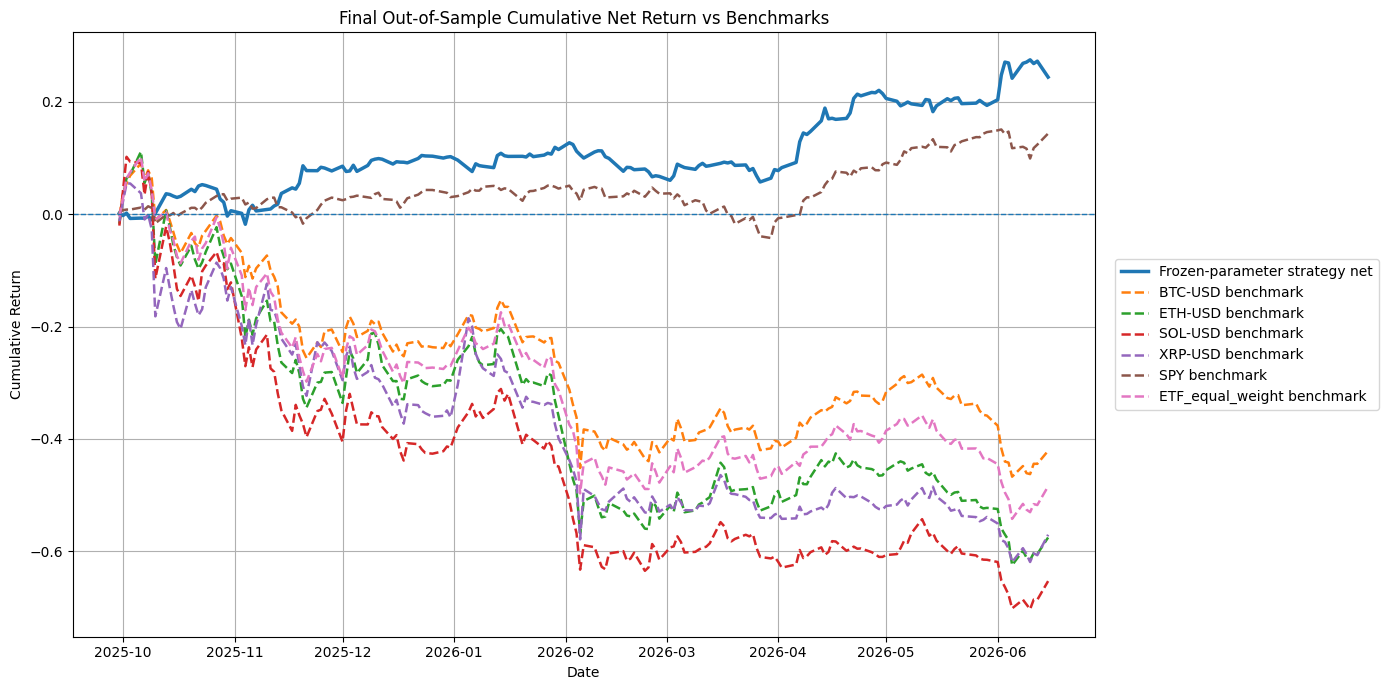

,benchmark,ann_alpha,alpha_tstat,beta,corr,r2
0,BTC-USD,31.92%,1.66,-0.00,-0.01,0.01%
1,ETH-USD,33.97%,1.72,0.02,0.08,0.67%
2,SOL-USD,32.16%,1.63,0.00,0.00,0.00%
3,XRP-USD,31.39%,1.61,-0.01,-0.04,0.14%
4,SPY,29.86%,1.57,0.11,0.10,1.00%
5,ETF_equal_weight,32.71%,1.70,0.01,0.03,0.07%


In [ ]:
# Final OOS test using the single frozen parameter set selected on the training sample.
final_oos_result = run_cvxpy_backtest_returns(
    entry_z=SELECTED_ENTRY_Z,
    risk_aversion=SELECTED_RISK_AVERSION,
    turnover_penalty=SELECTED_TURNOVER_PENALTY,
    lookback_beta=BASE_LOOKBACK_BETA,
    lookback_z=BASE_LOOKBACK_Z,
    start_date=OOS_START,
    end_date=OOS_END,
    calculation_end_date=OOS_END,
)

if final_oos_result is None:
    raise ValueError("Final OOS backtest produced no valid observations.")

bt_oos_final, wdf_oos_final = final_oos_result

final_oos_stats = perf_stats(bt_oos_final["net_ret"], bt_oos_final["turnover"])
final_oos_stats["entry_z"] = SELECTED_ENTRY_Z
final_oos_stats["risk_aversion"] = SELECTED_RISK_AVERSION
final_oos_stats["turnover_penalty"] = SELECTED_TURNOVER_PENALTY
final_oos_stats["final_cum_return"] = bt_oos_final["cum_net"].iloc[-1]
final_oos_stats["max_gross"] = bt_oos_final["gross_exposure"].max()
final_oos_stats["oos_start"] = OOS_START.date()
final_oos_stats["oos_end"] = OOS_END.date()

final_oos_results_df = pd.DataFrame([final_oos_stats])[[
    "oos_start",
    "oos_end",
    "entry_z",
    "risk_aversion",
    "turnover_penalty",
    "total_return",
    "ann_return",
    "ann_vol",
    "sharpe",
    "max_drawdown",
    "hit_rate",
    "avg_daily_turnover",
    "final_cum_return",
    "max_gross",
    "days",
]]
final_oos_results_df.index = ["Frozen-parameter OOS result"]

display(final_oos_results_df.style.format(formatters))


# Build OOS benchmark cumulative returns using the same OOS trading calendar.
def benchmark_returns_on_calendar(column: str, calendar_index: pd.Index) -> pd.Series:
    """Compute benchmark returns on the model calendar, then slice to the OOS index."""
    full_calendar = all_model_dates[all_model_dates <= calendar_index.max()]
    return (
        prices[column]
        .reindex(full_calendar)
        .pct_change(fill_method=None)
        .reindex(calendar_index)
        .fillna(0.0)
    )


oos_benchmark_cols = sorted(set(etf_info["Underlying"])) + ["SPY"]
bench_rets = pd.DataFrame(index=bt_oos_final.index)

for col in oos_benchmark_cols:
    if col in prices.columns:
        bench_rets[col] = benchmark_returns_on_calendar(col, bt_oos_final.index)

# Add an ETF equal-weight benchmark using included ETFs with available prices.
oos_etf_cols = [t for t in etf_info["ETF"] if t in prices.columns]
if oos_etf_cols:
    full_calendar = all_model_dates[all_model_dates <= bt_oos_final.index.max()]
    bench_rets["ETF_equal_weight"] = (
        prices[oos_etf_cols]
        .reindex(full_calendar)
        .pct_change(fill_method=None)
        .mean(axis=1)
        .reindex(bt_oos_final.index)
        .fillna(0.0)
    )

print("OOS benchmark columns included:", list(bench_rets.columns))

bench_cum = (1 + bench_rets).cumprod() - 1

# Plot the single final OOS strategy curve against benchmarks.
plt.figure(figsize=(14, 7))

plt.plot(
    bt_oos_final.index,
    bt_oos_final["cum_net"],
    linewidth=2.5,
    label="Frozen-parameter strategy net",
)

for col in bench_cum.columns:
    plt.plot(
        bench_cum.index,
        bench_cum[col],
        linewidth=1.8,
        linestyle="--",
        label=f"{col} benchmark",
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Final Out-of-Sample Cumulative Net Return vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
)
plt.grid(True)
plt.tight_layout()
plt.show()


# Optional: OOS alpha/beta diagnostics for the single frozen strategy.
oos_factor_rows = []

for benchmark in bench_rets.columns:
    aligned = pd.concat(
        [
            bt_oos_final["net_ret"].rename("strategy"),
            bench_rets[benchmark].rename("benchmark"),
        ],
        axis=1,
    ).dropna()

    if len(aligned) < 30 or aligned["benchmark"].var() == 0:
        continue

    X = sm.add_constant(aligned["benchmark"])
    model = sm.OLS(aligned["strategy"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    alpha_daily = model.params["const"]
    beta = model.params["benchmark"]

    oos_factor_rows.append({
        "benchmark": benchmark,
        "ann_alpha": alpha_daily * 252,
        "alpha_tstat": model.tvalues["const"],
        "beta": beta,
        "corr": aligned["strategy"].corr(aligned["benchmark"]),
        "r2": model.rsquared,
    })

oos_factor_df = pd.DataFrame(oos_factor_rows)
if not oos_factor_df.empty:
    display(
        oos_factor_df.style.format({
            "ann_alpha": "{:.2%}",
            "alpha_tstat": "{:.2f}",
            "beta": "{:.2f}",
            "corr": "{:.2f}",
            "r2": "{:.2%}",
        })
    )

## 16. Conclusion
The main takeaway is that the strategy shows evidence of an ETF-versus-underlying relative value effect, not simply a directional crypto trade. After selecting parameters only on the training sample and freezing them for the OOS test, the strategy earned a 24.43% total return from 2025-09-30 to 2026-06-15, with a 36.26% annualized return, 15.32% annualized volatility, and a 2.37 Sharpe ratio.

The result is especially interesting because the strategy had low beta and low correlation to BTC, ETH, SOL, XRP, SPY, and the ETF equal-weight benchmark. This supports the idea that the signal is capturing ETF/underlying dislocations rather than just taking hidden long crypto exposure.

That said, the results should still be framed carefully. Performance is sensitive to transaction costs, and the strategy has high average daily turnover. The economic story is likely tied to ETF trading hours, stale ETF prices, overnight crypto price discovery, and catch-up behavior between crypto ETFs and their underlying assets. Therefore, the best interpretation is that this is a promising relative-value signal that deserves further testing, rather than definitive proof of persistent mean reversion.